# K-means — Theoretical Note

## Overview
K-means is an iterative, partition-based clustering algorithm that partitions n observations into k clusters so as to minimize intra-cluster variance. Each cluster is represented by its centroid (mean of member points). It assumes clusters are roughly spherical and of similar scale.

## Objective
K-means aims to minimize the within-cluster sum of squared Euclidean distances (WCSS):
  
  $$J = \sum_{i=1..k} \sum_{x in C_i} ||x - μ_i||^2$$
  
where $C_i$ is cluster $i$ and $μ_i$ is its centroid.

## Algorithm (Lloyd’s method)
1. Initialize $k$ centroids (randomly or by a heuristic).  
2. Assignment step: assign each point to the nearest centroid (Euclidean distance).  
3. Update step: recompute each centroid as the mean of points assigned to it.  
4. Repeat steps 2–3 until assignments do not change or change in $J$ is below a threshold.

## Initialization and Local Optima
K-means optimizes a non-convex objective and can converge to local minima; initialization affects result. Common strategies: random samples, k-means++ (probabilistic seeding to improve spread), or multiple restarts and selecting the best solution by lowest $J$.

## Convergence and Complexity
- Converges in a finite number of iterations to a (local) stationary point because each step does not increase $J$.  
- Complexity per iteration: O(n k d) for n points in d dimensions. Number of iterations may vary; practical performance is typically acceptable for moderate $k$ and $d$.

## Strengths
- Simple, fast, and scalable to large datasets.  
- Works well when clusters are spherical, well-separated, and similar in size.

## Limitations
- Assumes Euclidean geometry and convex (spherical) clusters.  
- Sensitive to outliers and feature scaling.  
- Requires a pre-specified $k$.  
- May produce poor results for clusters of varying size, density, or non-globular shape.

## Practical Considerations
- Standardize features (e.g., z-score) before clustering.  
- Choose $k$ via domain knowledge, elbow method (plot WCSS vs k), silhouette score, or information criteria.  
- Use k-means++ for robust initialization; run multiple restarts to reduce risk of bad local minima.  
- Consider alternatives (Gaussian Mixture Models, DBSCAN, spectral clustering) when assumptions are violated.

## Variants and Extensions
- k-means++ (better initialization).  
- Mini-batch k-means (stochastic updates for large datasets).  
- Spherical k-means (cosine similarity).  
- Kernel k-means (nonlinear cluster boundaries).

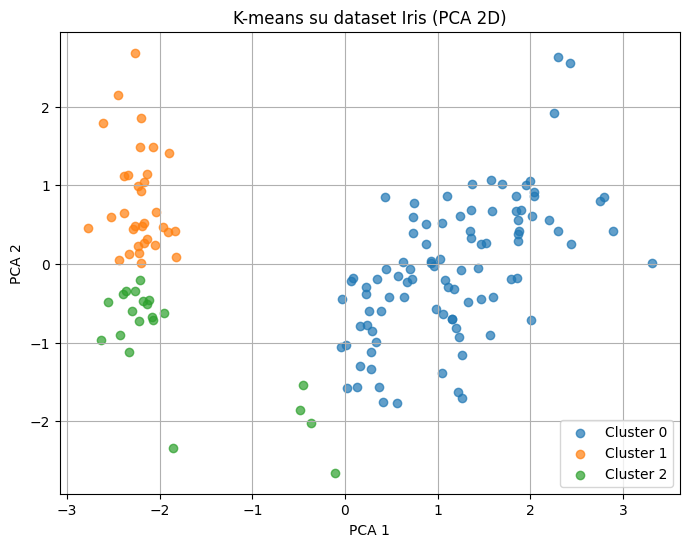

Inertia: 191.02473685317963
Cluster counts:
cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# carica un dataset reale
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# standardizza le feature prima del clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# applica K-means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# aggiungi etichette al dataframe
X["cluster"] = labels

# riduzione dimensionale per il grafico
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# grafico dei cluster
plt.figure(figsize=(8, 6))
for cluster in range(k):
    mask = labels == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title("K-means su dataset Iris (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

# informazioni di base
print("Inertia:", kmeans.inertia_)
print("Cluster counts:")
print(X["cluster"].value_counts())